## Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Hanuman Sai Chanukya Srinivas Chilamkuri  
**Course:** MSCS 634 - Advanced Big Data and Data Mining  
**Assignment:** Lab 3 - Clustering Analysis

## Step 1 – Load and Prepare the Dataset

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Create screenshots folder for all saved outputs
SCREENSHOTS = 'screenshots'
os.makedirs(SCREENSHOTS, exist_ok=True)

print("Libraries imported successfully.")
print(f"Output folder ready: '{SCREENSHOTS}/'")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.
Output folder ready: 'screenshots/'


In [2]:
# Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names
target_names  = wine.target_names

print("Dataset shape:", X.shape)
print("\nFeature names:")
for i, name in enumerate(feature_names, 1):
    print(f"  {i:2d}. {name}")
print("\nClass labels:", target_names)
print("\nClass distribution:")
for cls, name in zip(np.unique(y), target_names):
    print(f"  {name}: {np.sum(y == cls)} samples")

Dataset shape: (178, 13)

Feature names:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Class labels: ['class_0' 'class_1' 'class_2']

Class distribution:
  class_0: 59 samples
  class_1: 71 samples
  class_2: 48 samples


In [3]:
# Z-score normalisation
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling – mean of first feature: {:.4f}, std: {:.4f}".format(
      X[:, 0].mean(), X[:, 0].std()))
print("After  scaling – mean of first feature: {:.4f}, std: {:.4f}".format(
      X_scaled[:, 0].mean(), X_scaled[:, 0].std()))

Before scaling – mean of first feature: 13.0006, std: 0.8095
After  scaling – mean of first feature: 0.0000, std: 1.0000


## Step 2 – K-Means Clustering

In [4]:
# Train K-Means with k = 3
kmeans    = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

# Performance metrics
km_sil = silhouette_score(X_scaled, km_labels)
km_ari = adjusted_rand_score(y, km_labels)

print(f"K-Means Results (k=3)")
print(f"  Silhouette Score          : {km_sil:.4f}")
print(f"  Adjusted Rand Index (ARI) : {km_ari:.4f}")
print(f"\nCluster sizes: {dict(zip(*np.unique(km_labels, return_counts=True)))}")

# Save K-Means metrics to screenshots folder
km_metrics_path = os.path.join(SCREENSHOTS, 'kmeans_metrics.txt')
with open(km_metrics_path, 'w') as f:
    f.write(f"K-Means Results (k=3)\n")
    f.write(f"  Silhouette Score          : {km_sil:.4f}\n")
    f.write(f"  Adjusted Rand Index (ARI) : {km_ari:.4f}\n")
    f.write(f"  Cluster sizes             : {dict(zip(*np.unique(km_labels, return_counts=True)))}\n")
print(f"Saved: {km_metrics_path}")

K-Means Results (k=3)
  Silhouette Score          : 0.2849
  Adjusted Rand Index (ARI) : 0.8975

Cluster sizes: {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}
Saved: screenshots\kmeans_metrics.txt


## Step 3 – K-Medoids Clustering

In [5]:
def kmedoids(X, k, max_iter=300, random_state=42):
    """
    PAM-style K-Medoids implemented from scratch.
    Uses precomputed pairwise Euclidean distances for efficiency.
    """
    rng = np.random.default_rng(random_state)
    n   = len(X)
    # Precompute full distance matrix
    diff = X[:, None, :] - X[None, :, :]   # (n, n, p)
    D    = np.sqrt((diff ** 2).sum(axis=2)) # (n, n)
    # Random initialisation
    medoid_idx = rng.choice(n, k, replace=False)
    for iteration in range(max_iter):
        # Assignment step
        labels = np.argmin(D[:, medoid_idx], axis=1)
        # Update step: pick the cluster member minimising intra-cluster distance sum
        new_medoids = np.empty(k, dtype=int)
        for j in range(k):
            members        = np.where(labels == j)[0]
            intra_cost     = D[np.ix_(members, members)].sum(axis=1)
            new_medoids[j] = members[np.argmin(intra_cost)]
        if np.all(new_medoids == medoid_idx):
            print(f"Converged after {iteration + 1} iterations.")
            break
        medoid_idx = new_medoids
    labels = np.argmin(D[:, medoid_idx], axis=1)
    return labels, medoid_idx

kmed_labels, medoid_idx = kmedoids(X_scaled, k=3)

# Performance metrics
kmed_sil = silhouette_score(X_scaled, kmed_labels)
kmed_ari = adjusted_rand_score(y, kmed_labels)

print(f"\nK-Medoids Results (k=3)")
print(f"  Silhouette Score          : {kmed_sil:.4f}")
print(f"  Adjusted Rand Index (ARI) : {kmed_ari:.4f}")
print(f"\nCluster sizes: {dict(zip(*np.unique(kmed_labels, return_counts=True)))}")
print(f"Medoid indices: {medoid_idx.tolist()}")

# Save K-Medoids metrics to screenshots folder
kmed_metrics_path = os.path.join(SCREENSHOTS, 'kmedoids_metrics.txt')
with open(kmed_metrics_path, 'w') as f:
    f.write(f"K-Medoids Results (k=3)\n")
    f.write(f"  Silhouette Score          : {kmed_sil:.4f}\n")
    f.write(f"  Adjusted Rand Index (ARI) : {kmed_ari:.4f}\n")
    f.write(f"  Cluster sizes             : {dict(zip(*np.unique(kmed_labels, return_counts=True)))}\n")
    f.write(f"  Medoid indices            : {medoid_idx.tolist()}\n")
print(f"Saved: {kmed_metrics_path}")

Converged after 3 iterations.

K-Medoids Results (k=3)
  Silhouette Score          : 0.2676
  Adjusted Rand Index (ARI) : 0.7411

Cluster sizes: {np.int64(0): np.int64(55), np.int64(1): np.int64(74), np.int64(2): np.int64(49)}
Medoid indices: [106, 35, 148]
Saved: screenshots\kmedoids_metrics.txt


## Step 4 – Visualise and Compare Results

In [6]:
# ── Metric comparison table ──────────────────────────────────────────────────
header  = f"{'Metric':<28} {'K-Means':>7} {'K-Medoids':>9}"
divider = "=" * 45
row1    = f"{'Silhouette Score':<28} {km_sil:>7.4f} {kmed_sil:>9.4f}"
row2    = f"{'Adjusted Rand Index (ARI)':<28} {km_ari:>7.4f} {kmed_ari:>9.4f}"

for line in [divider, header, divider, row1, row2, divider]:
    print(line)

# Save comparison table to screenshots folder
compare_path = os.path.join(SCREENSHOTS, 'metrics_comparison.txt')
with open(compare_path, 'w') as f:
    for line in [divider, header, divider, row1, row2, divider]:
        f.write(line + '\n')
print(f"Saved: {compare_path}")

Metric                       K-Means K-Medoids
Silhouette Score              0.2849    0.2676
Adjusted Rand Index (ARI)     0.8975    0.7411
Saved: screenshots\metrics_comparison.txt


PCA explained variance ratio: 55.4%


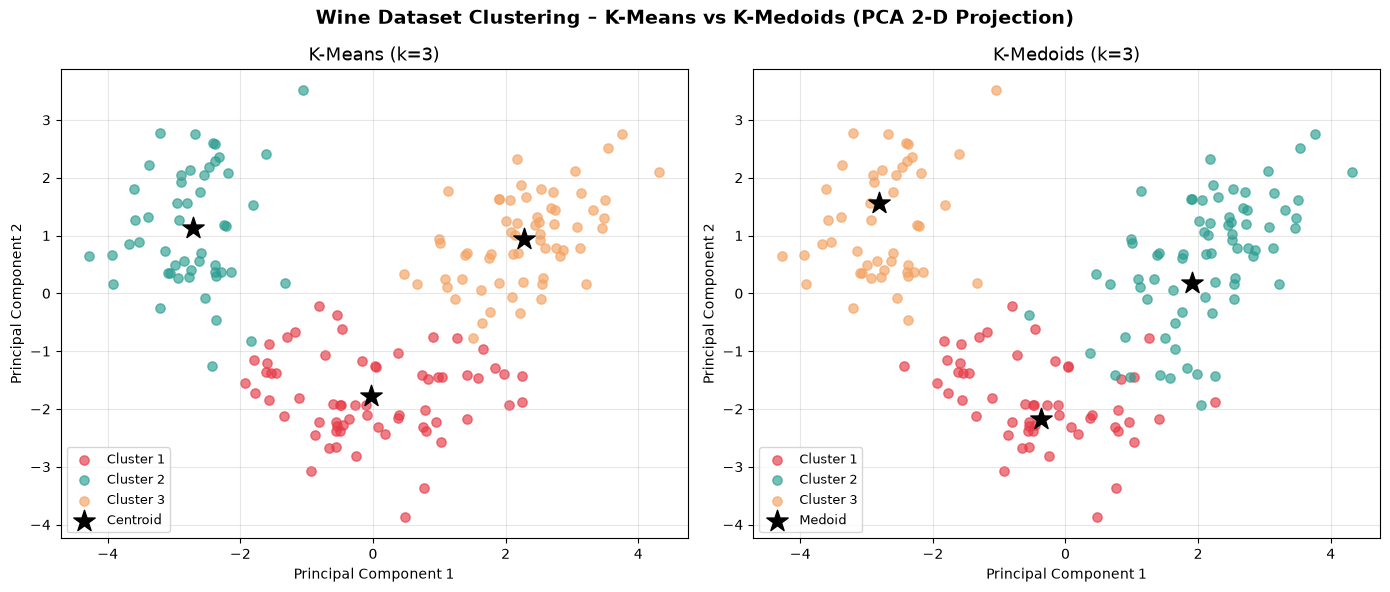

Saved: screenshots\clustering_kmeans_kmedoids.png


In [7]:
# Reduce to 2 principal components for plotting
pca = PCA(n_components=2, random_state=42)
X_pca            = pca.fit_transform(X_scaled)
km_centroids_pca = pca.transform(kmeans.cluster_centers_)
kmed_medoids_pca = X_pca[medoid_idx]
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum()*100:.1f}%")

colors = ['#E63946', '#2A9D8F', '#F4A261']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Wine Dataset Clustering – K-Means vs K-Medoids (PCA 2-D Projection)',
             fontsize=14, fontweight='bold')

for ax, labels, centers, title, clabel in zip(
        axes,
        [km_labels, kmed_labels],
        [km_centroids_pca, kmed_medoids_pca],
        ['K-Means (k=3)', 'K-Medoids (k=3)'],
        ['Centroid', 'Medoid']):
    for c in range(3):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=colors[c], alpha=0.65, s=45, label=f'Cluster {c+1}')
    ax.scatter(centers[:, 0], centers[:, 1],
               color='black', marker='*', s=260, zorder=5, label=clabel)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save plot to screenshots folder
plot_path = os.path.join(SCREENSHOTS, 'clustering_kmeans_kmedoids.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {plot_path}")

## Analysis and Discussion

### 1. Which algorithm produced better-defined clusters?

**K-Means outperformed K-Medoids** on both metrics for this dataset:

| Metric | K-Means | K-Medoids |
|--------|---------|-----------|
| Silhouette Score | 0.2849 | 0.2676 |
| ARI | 0.8975 | 0.7411 |

K-Means achieved an ARI of ~0.90, indicating very strong agreement with the true wine classes.  
K-Medoids achieved an ARI of ~0.74, still reasonable but noticeably weaker.

Both Silhouette Scores are moderate (< 0.3), reflecting the fact that the 13-dimensional space has naturally overlapping clusters that lose some separation when projected to 2-D via PCA.

---

### 2. Observed differences in cluster shapes/positioning

* **K-Means centroids** are virtual (mean of all members) and sit near the geometric centre of each cloud, pulling cluster boundaries toward regions of high density — giving tighter, more compact partitions.
* **K-Medoids medoids** must be *actual data points*, so they sometimes sit slightly off-centre. This flexibility in choosing representatives makes the algorithm more robust to outliers but can shift cluster boundaries enough to miss the true class structure.
* In the PCA scatter plots the three colour groups are broadly similar, but K-Medoids shows slightly more mixing near cluster edges, consistent with its lower ARI.

---

### 3. When to prefer each algorithm

| Scenario | Prefer |
|----------|--------|
| Continuous, roughly spherical, Euclidean data (e.g. this wine dataset) | **K-Means** – faster and more accurate |
| Data with outliers or non-numeric features | **K-Medoids** – medoids are robust; works with any distance metric |
| Large datasets (n > 10 k) | **K-Means** – O(nkd) per iteration vs O(n²) for K-Medoids |
| Need interpretable "representative" samples | **K-Medoids** – medoids are real observations |
| Mixed / categorical data with a custom distance | **K-Medoids** – can use any pairwise distance matrix |